In [1]:
%pip install pandas matplotlib seaborn scikit-learn transformers ipywidgets
%pip install torch --index-url https://download.pytorch.org/whl/cu130

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.


Shape: (24783, 7)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...



Columns:
['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Data types:
Unnamed: 0            int64
count                 int64
hate_speech           int64
offensive_language    int64
neither               int64
class                 int64
tweet                   str
dtype: object

Missing values:


,missing_count
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0



Duplicate rows: 0

Numeric summary:


...

,count,unique,top,freq
tweet,24783,24783,!!! RT @mayasolovely: As a woman you shouldn't...,1



Created cleaned text column: tweet_clean


,tweet,tweet_clean
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldn t complain about cle...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats cold tyga dwn bad for cuffin dat h...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she start...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true or...


,count,percentage
class,,
0,1430,5.77
1,19190,77.43
2,4163,16.80


C:\Users\mwper\AppData\Local\Temp\ipykernel_10560\47506999.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_col, order=class_counts.index, palette="viridis")


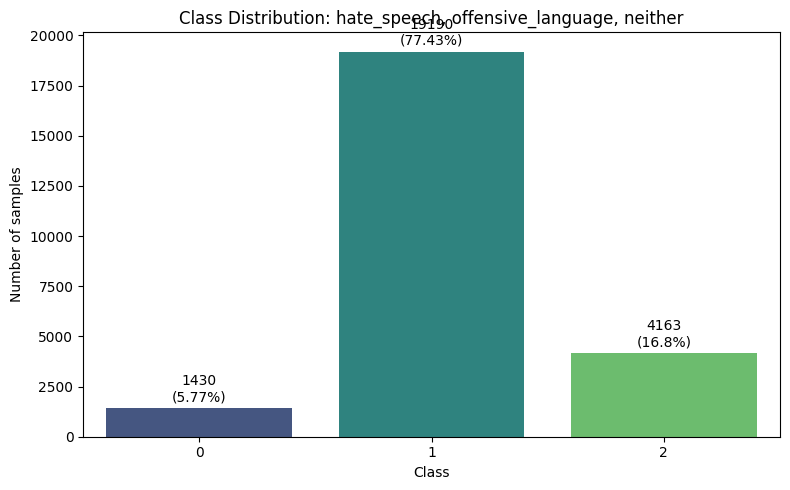


Class hate_speech - 5 examples


,class,tweet,tweet_clean
0,0,@AustinG1135 I do not like talking to you fagg...,i do not like talking to you faggot and i did ...
1,0,RT @mitchmancuso: @BrantPrintup:What straight ...,rt what straight guys take a picture of themse...
2,0,"@clinchmtn316 @sixonesixband AMERICA today, th...",america today the rule of thumb is when in dou...
3,0,"@STACCS_WNT_FOLD you tell me, coon.",you tell me coon
4,0,RT @FAAMMoverALL: This nigguh Chris Paul,rt this nigguh chris paul



Class offensive_language - 5 examples


,class,tweet,tweet_clean
0,1,Why is it everytime I go to cracker barrel the...,why is it everytime i go to cracker barrel the...
1,1,"Run that nigga, you don't want that nigga, but...",run that nigga you don t want that nigga but i...
2,1,I need a girl from Jamaica I can't fuck with t...,i need a girl from jamaica i can t fuck with t...
3,1,RT @ShadowBeatz_Inc: I know you have me blocke...,rt i know you have me blocked but next week bitch
4,1,Put ya hands up if you a Grade A bitch,put ya hands up if you a grade a bitch



Class neither - 5 examples


,class,tweet,tweet_clean
0,2,RT @chicagotribune: Chicago will not refund $7...,rt chicago will not refund million made from r...
1,2,"Sometimes, even I gotta tell these hoes to gro...",sometimes even i gotta tell these hoes to grow...
2,2,&#8216;Chillin&#8217; With My Homie Or What&#8...,chillin with my homie or what s left of him br...
3,2,.@CoryBooker is running around town delivering...,is running around town delivering food to peop...
4,2,RT @McNarstle: ...and rounding out our CNN Ebo...,rt and rounding out our cnn ebola panel tonigh...


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/labeled_data.csv")

# Basic overview
print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumeric summary:")
display(df.describe().T)

print("\nCategorical summary:")
display(df.describe(include=["object", "category"]).T if len(df.select_dtypes(include=["object", "category"]).columns) else pd.DataFrame({"info": ["No categorical columns"]}))

# Clean text column: URLs, @mentions, hashtags, special characters
text_col = "tweet" if "tweet" in df.columns else df.select_dtypes(include=["object", "category"]).columns[0]

df[f"{text_col}_clean"] = (
    df[text_col]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"http\S+|www\.\S+", "", regex=True)   # remove URLs
    .str.replace(r"@\w+", "", regex=True)               # remove @mentions
    .str.replace(r"#(\w+)", r"\1", regex=True)          # keep hashtag word, remove #
    .str.replace(r"[^a-z\s]", " ", regex=True)          # remove special characters/numbers
    .str.replace(r"\s+", " ", regex=True)               # normalize spaces
    .str.strip()
)

print(f"\nCreated cleaned text column: {text_col}_clean")
display(df[[text_col, f"{text_col}_clean"]].head())

class_names = ["hate_speech", "offensive_language", "neither"]
target_col = "class"

# Visualize class imbalance
class_counts = df[target_col].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

display(
    pd.DataFrame({
        "count": class_counts,
        "percentage": class_pct
    })
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_col, order=class_counts.index, palette="viridis")

plt.title(f"Class Distribution: {', '.join(class_names)}")
plt.xlabel("Class")
plt.ylabel("Number of samples")

for i, cls in enumerate(class_counts.index):
    count = class_counts.loc[cls]
    pct = class_pct.loc[cls]
    ax.text(i, count + max(class_counts) * 0.01, f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


sample_cols = [target_col, text_col]
clean_col = f"{text_col}_clean"
if clean_col in df.columns:
    sample_cols.append(clean_col)

for cls_value in sorted(df[target_col].dropna().unique()):
    print(f"\nClass {class_names[cls_value]} - 5 examples")
    display(
        df.loc[df[target_col] == cls_value, sample_cols]
          .sample(n=min(5, (df[target_col] == cls_value).sum()), random_state=42)
          .reset_index(drop=True)
    )

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Keep required columns
df = df[["tweet_clean", "class"]].dropna()
X = df["tweet_clean"].astype(str)
y = df["class"].astype(int)

# Train/validation/test split (70/15/15), stratified by class
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

# Baseline models with TF-IDF
models = {
    "SVM": LinearSVC(),
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=None),
    "RandomForest": RandomForestClassifier(n_estimators=100, n_jobs=None)
}

baseline_predictions = {}
baseline_results = []

for name, clf in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )),
        ("clf", clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    baseline_predictions[name] = {y_test.name: y_test, "y_pred": y_pred}

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted")
    })

    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Train size: 17348
Validation size: 3717
Test size: 3718

=== SVM ===
Accuracy: 0.8932
Macro F1: 0.7066
                    precision    recall  f1-score   support

       hate_speech     0.5327    0.2664    0.3551       214
offensive_language     0.9234    0.9510    0.9370      2879
           neither     0.8142    0.8416    0.8277       625

          accuracy                         0.8932      3718
         macro avg     0.7568    0.6863    0.7066      3718
      weighted avg     0.8826    0.8932    0.8852      3718


=== LogisticRegression ===
Accuracy: 0.8956
Macro F1: 0.6783
                    precision    recall  f1-score   support

       hate_speech     0.6792    0.1682    0.2697       214
offensive_language     0.9099    0.9677    0.9379      2879
           neither     0.8425    0.8128    0.8274       625

          accuracy                         0.8956      3718
         macro avg     0.8105    0.6496    0.6783      3718
      weighted avg     0.8853    0.8956    0.8808 

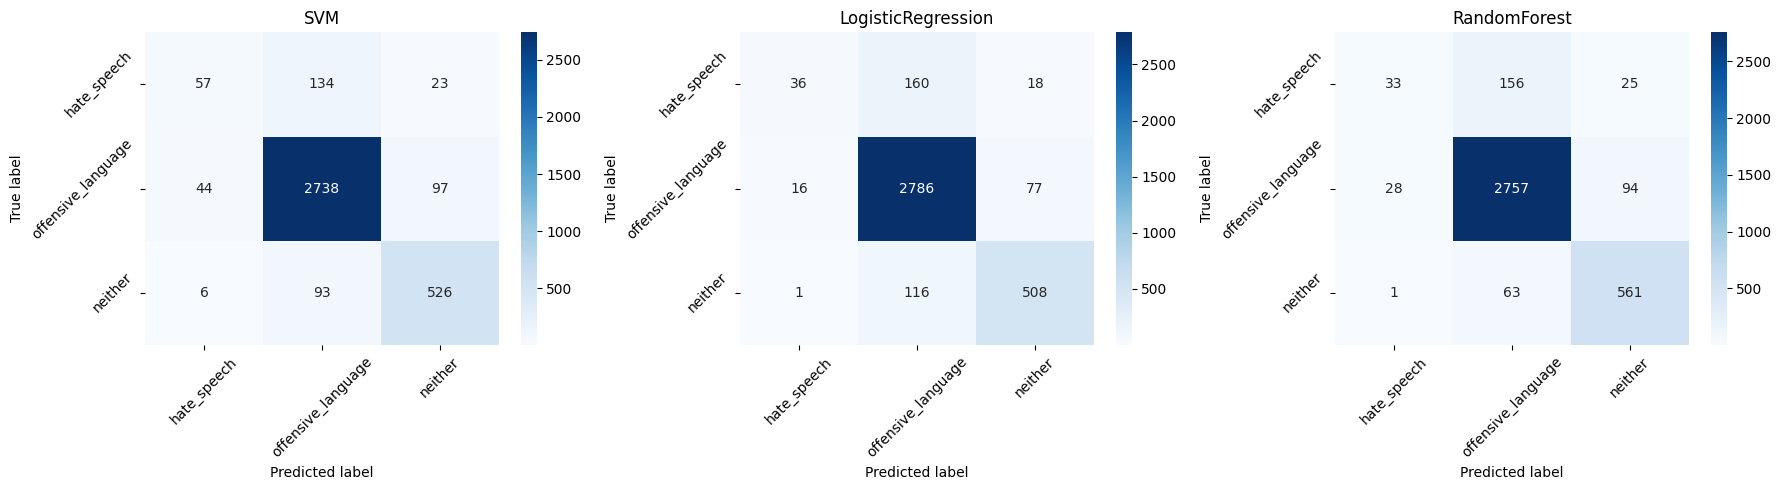


Baseline Model Comparison:


,Model,Accuracy,Macro F1,Weighted F1
0,SVM,0.893222,0.706621,0.885158
1,RandomForest,0.901291,0.680220,0.887535
2,LogisticRegression,0.895643,0.678305,0.880848



Classification Report for Best Model: SVM
                    precision    recall  f1-score   support

       hate_speech     0.5327    0.2664    0.3551       214
offensive_language     0.9234    0.9510    0.9370      2879
           neither     0.8142    0.8416    0.8277       625

          accuracy                         0.8932      3718
         macro avg     0.7568    0.6863    0.7066      3718
      weighted avg     0.8826    0.8932    0.8852      3718



In [7]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (name, results) in zip(axes, baseline_predictions.items()):
    cm = confusion_matrix(results[y_test.name], results["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_yticklabels(class_names, rotation=45)
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


comparison_df = pd.DataFrame(baseline_results).sort_values(by="Macro F1", ascending=False).reset_index(drop=True)

print("\nBaseline Model Comparison:")
display(comparison_df)

# Classification report for best model
best_model_name = comparison_df.loc[0, "Model"]
best_results = baseline_predictions[best_model_name]

print(f"\nClassification Report for Best Model: {best_model_name}")
print(classification_report(best_results[y_test.name], best_results["y_pred"], target_names=class_names, digits=4))

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Config
model_name = "albert-base-v2"
num_labels = len(class_names)
max_length = 128
batch_size = 32
epochs = 3
lr = 1e-5

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

model.dropout.p = 0.2

model.to(device)

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist() if hasattr(texts, "tolist") else list(texts)
        self.labels = labels.tolist() if hasattr(labels, "tolist") else list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# # Oversample training data to match the majority class size
train_df = pd.DataFrame({
    "tweet_clean": X_train.values,
    "class": y_train.values
})

max_count = train_df["class"].value_counts().max()

balanced_parts = []
for cls, grp in train_df.groupby("class"):
    balanced_parts.append(
        grp.sample(n=max_count, replace=True, random_state=42)
    )

train_balanced_df = (
    pd.concat(balanced_parts, axis=0)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

X_train_balanced = train_balanced_df["tweet_clean"]
y_train_balanced = train_balanced_df["class"].astype(int)

print("Class distribution after oversampling:")
print(y_train_balanced.value_counts().sort_index())

train_ds = TweetDataset(X_train_balanced, y_train_balanced, tokenizer, max_length=max_length)
val_ds = TweetDataset(X_val, y_val, tokenizer, max_length=max_length)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


history = {
    'train_loss': [], 'train_acc': [], 'train_macro_f1': [],
    'val_loss': [], 'val_acc': [], 'val_macro_f1': []
}

for epoch in range(epochs):
    # ---- Train ----
    model.train()
    
    train_loss_total = 0
    train_correct = 0
    train_total = 0

    train_preds, train_labels = [], []

    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        out = model(**batch)
        loss = out.loss
        loss.backward()
        optimizer.step()

        # Track metrics
        train_loss_total += loss.item()
        preds = torch.argmax(out.logits, dim=-1)
        labels = batch["labels"]
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        train_loss_total += loss.item()

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        # Progress update every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | "
                    f"Loss: {loss.item():.4f}")

    avg_train_loss = train_loss_total / len(train_loader)
    train_acc = train_correct / train_total
    train_macro_f1 = f1_score(train_labels, train_preds, average="macro")

    # ---- Validate ----
    model.eval()
    val_loss_total = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            labels = batch["labels"].to(device)
            batch = {k: v.to(device) for k, v in batch.items()}

            out = model(**batch)
            val_loss_total += out.loss.item()

            preds = torch.argmax(out.logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss_total / len(val_loader)
    val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
    val_macro_f1 = f1_score(val_labels, val_preds, average="macro")

    # Store history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['train_macro_f1'].append(train_macro_f1)
    history['val_macro_f1'].append(val_macro_f1)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train Macro F1: {train_macro_f1:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )

Using device: cuda


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class distribution after oversampling:
class
0    13433
1    13433
2    13433
Name: count, dtype: int64
  Epoch 1 | Batch 50/1260 | Loss: 0.9078
  Epoch 1 | Batch 100/1260 | Loss: 0.7613
  Epoch 1 | Batch 150/1260 | Loss: 0.5285
  Epoch 1 | Batch 200/1260 | Loss: 0.3674
  Epoch 1 | Batch 250/1260 | Loss: 0.4774
  Epoch 1 | Batch 300/1260 | Loss: 0.5958
  Epoch 1 | Batch 350/1260 | Loss: 0.3818
  Epoch 1 | Batch 400/1260 | Loss: 0.3092
  Epoch 1 | Batch 450/1260 | Loss: 0.4934
  Epoch 1 | Batch 500/1260 | Loss: 0.3216
  Epoch 1 | Batch 550/1260 | Loss: 0.2660
  Epoch 1 | Batch 600/1260 | Loss: 0.2574
  Epoch 1 | Batch 650/1260 | Loss: 0.2247
  Epoch 1 | Batch 700/1260 | Loss: 0.1850
  Epoch 1 | Batch 750/1260 | Loss: 0.3375
  Epoch 1 | Batch 800/1260 | Loss: 0.3488
  Epoch 1 | Batch 850/1260 | Loss: 0.2164
  Epoch 1 | Batch 900/1260 | Loss: 0.2195
  Epoch 1 | Batch 950/1260 | Loss: 0.3900
  Epoch 1 | Batch 1000/1260 | Loss: 0.1589
  Epoch 1 | Batch 1050/1260 | Loss: 0.2820
  Epoch 1 | B

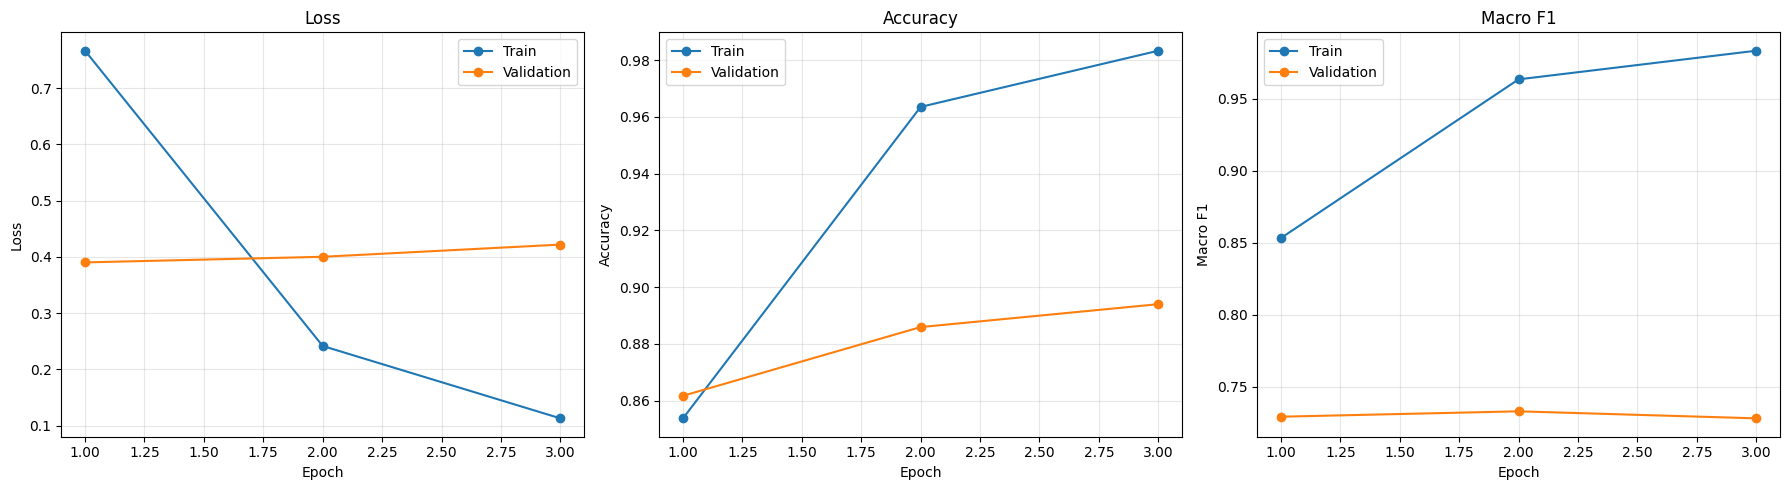

Test Accuracy: 0.8975
Test Macro F1: 0.7304

Classification Report:
                    precision    recall  f1-score   support

       hate_speech     0.3938    0.3551    0.3735       214
offensive_language     0.9342    0.9423    0.9383      2879
           neither     0.8824    0.8768    0.8796       625

          accuracy                         0.8975      3718
         macro avg     0.7368    0.7248    0.7304      3718
      weighted avg     0.8944    0.8975    0.8959      3718



In [6]:

history_df = pd.DataFrame(history)
epochs_range = range(1, len(history_df) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history_df["train_loss"], marker="o", label="Train")
axes[0].plot(epochs_range, history_df["val_loss"], marker="o", label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_df["train_acc"], marker="o", label="Train")
axes[1].plot(epochs_range, history_df["val_acc"], marker="o", label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history_df["train_macro_f1"], marker="o", label="Train")
axes[2].plot(epochs_range, history_df["val_macro_f1"], marker="o", label="Validation")
axes[2].set_title("Macro F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro F1")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on test set
test_ds = TweetDataset(X_test, y_test, tokenizer, max_length=max_length)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

test_preds, test_labels = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].to(device)
        batch = {k: v.to(device) for k, v in batch.items()}

        out = model(**batch)
        preds = torch.argmax(out.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = (np.array(test_preds) == np.array(test_labels)).mean()
test_macro_f1 = f1_score(test_labels, test_preds, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

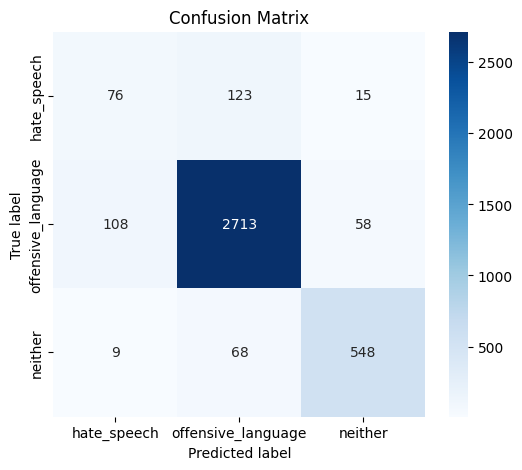

In [8]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [9]:
# Misclassified examples
misclassified_indices = np.where(np.array(test_preds) != np.array(test_labels))[0]
misclassified_df = pd.DataFrame({
    "tweet": X_test.iloc[misclassified_indices].values,
    "true_label": [class_names[i] for i in np.array(test_labels)[misclassified_indices]],
    "predicted_label": [class_names[i] for i in np.array(test_preds)[misclassified_indices]]
})

print("\nMisclassified Examples:")
display(misclassified_df.head(10))


Misclassified Examples:


,tweet,true_label,predicted_label
0,hi ho,neither,offensive_language
1,lets go hoosiers iubb,neither,offensive_language
2,rt half of it will be about how you became ghe...,offensive_language,neither
3,delete now you bitch ass nigga rt if the redsk...,hate_speech,offensive_language
4,aww y u so mad tho a successful man lmfao hut ...,hate_speech,offensive_language
5,rt todays horoscope you re still a hoe that is...,neither,offensive_language
6,rt rt for every bad bitch there is a nigga who...,hate_speech,offensive_language
7,hoes thnk they won when the nigga thats ridin ...,hate_speech,offensive_language
8,they already have are you retarded,offensive_language,hate_speech
9,rt not just cause of hoes go to jail cause of ...,hate_speech,offensive_language
